# Machine Learning Based Automatic Modulation Classification of Wireless Signals

## Overview
This project focuses on classifying different digital modulation schemes (such as BPSK, QPSK, QAM) using machine learning techniques. The dataset consists of raw I/Q signal samples, and multiple supervised learning models are applied to identify the modulation type.

## Objectives
- Understand signal representation using I/Q components
- Convert raw signal data into machine learning features
- Train and compare multiple classification models
- Evaluate performance using metrics and visualizations
- Apply PCA for dimensionality reduction

In [1]:
import sys

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Loading

The RadioML dataset is used in this project. It contains simulated radio signals for different modulation schemes under varying Signal-to-Noise Ratio (SNR) conditions.

Each data point consists of:
- A tuple (modulation type, SNR)
- A set of signal samples

The dataset is loaded using a flexible path system to ensure compatibility across different environments such as Google Colab and Jupyter Notebook.

In [2]:
import pickle
import numpy as np
import os

# Try multiple paths (Colab + Local)
possible_paths = [
    '/content/drive/MyDrive/colab_data/RML2016.10a_dict.pkl',  # Colab
    '../data/RML2016.10a_dict.pkl',                            # Local (recommended)
    'data/RML2016.10a_dict.pkl'
]

file_path = None

for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError("Dataset not found in expected locations.")

# Load dataset
with open(file_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(f"Dataset loaded from: {file_path}")
print(f"Total classes (modulation, SNR pairs): {len(data)}")

Dataset loaded from: /content/drive/MyDrive/colab_data/RML2016.10a_dict.pkl
Total classes (modulation, SNR pairs): 220


## 2. Data Understanding

The dataset is structured as a dictionary where:
- Keys: (modulation type, SNR)
- Values: Arrays of signal samples

Each signal sample has shape (2, 128):
- 2 represents the I (In-phase) and Q (Quadrature) components
- 128 represents time samples

Understanding this structure is crucial before applying machine learning techniques.

In [3]:
# Inspect one sample
key = list(data.keys())[0]
print("Sample key:", key)
print("Signal shape:", data[key][0].shape)

Sample key: ('QPSK', 2)
Signal shape: (2, 128)


In [4]:
# Extract unique modulations and SNR values

mods = set()
snrs = set()

for (mod, snr) in data.keys():
    mods.add(mod)
    snrs.add(snr)

mods = sorted(list(mods))
snrs = sorted(list(snrs))

print("Modulation types:", mods)
print("Number of modulations:", len(mods))

print("\nSNR values:", snrs[:10], "...")  # print first few
print("Total SNR levels:", len(snrs))

Modulation types: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
Number of modulations: 11

SNR values: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2] ...
Total SNR levels: 20


## 3. Data Preprocessing

To prepare the data for machine learning:

- Each signal (2 × 128) is flattened into a 256-dimensional vector
- Labels (modulation types) are stored separately
- A subset of samples is used to reduce computation time

This transformation allows traditional ML models to process signal data.

In [5]:
X = []
y = []

max_samples_per_pair = 200  # per (mod, snr)

for (mod, snr), signals in data.items():
    for i, signal in enumerate(signals[:max_samples_per_pair]):
        X.append(signal.flatten())
        y.append(mod)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (44000, 256)
y shape: (44000,)


### Label Encoding

Machine learning models require numerical labels. Therefore, modulation types (e.g., BPSK, QPSK) are converted into integer values using LabelEncoder.

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']


### Train-Test Split

The dataset is divided into training and testing sets:
- 80% for training
- 20% for testing

Stratified sampling is used to maintain class distribution across both sets.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (35200, 256)
Test size: (8800, 256)


### Feature Scaling

Standardization is applied to ensure all features have zero mean and unit variance. This improves the performance of distance-based models like KNN and SVM.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Model Training

Multiple machine learning models are trained to classify modulation schemes:

- K-Nearest Neighbors (KNN)
- Linear Support Vector Machine (SVM)
- Logistic Regression
- Decision Tree
- Random Forest

These models are chosen to compare different learning approaches.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluate
knn_acc = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.2771590909090909


In [10]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm = LinearSVC(max_iter=3000)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred))

Linear SVM Accuracy: 0.15420454545454546


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.15261363636363637


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, n_jobs=-1)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

Random Forest Accuracy: 0.36511363636363636


## 5. Model Evaluation

Model performance is evaluated using:
- Accuracy
- Classification Report (Precision, Recall, F1-score)
- Confusion Matrix

These metrics help in understanding how well the models classify different modulation types.

In [14]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Random Forest Classification Report:

              precision    recall  f1-score   support

        8PSK       0.18      0.18      0.18       800
      AM-DSB       0.58      0.42      0.49       800
      AM-SSB       0.23      0.67      0.34       800
        BPSK       0.44      0.38      0.41       800
       CPFSK       0.53      0.47      0.50       800
        GFSK       0.66      0.50      0.57       800
        PAM4       0.59      0.43      0.49       800
       QAM16       0.23      0.20      0.22       800
       QAM64       0.30      0.28      0.29       800
        QPSK       0.24      0.17      0.20       800
        WBFM       0.53      0.33      0.41       800

    accuracy                           0.37      8800
   macro avg       0.41      0.37      0.37      8800
weighted avg       0.41      0.37      0.37      8800



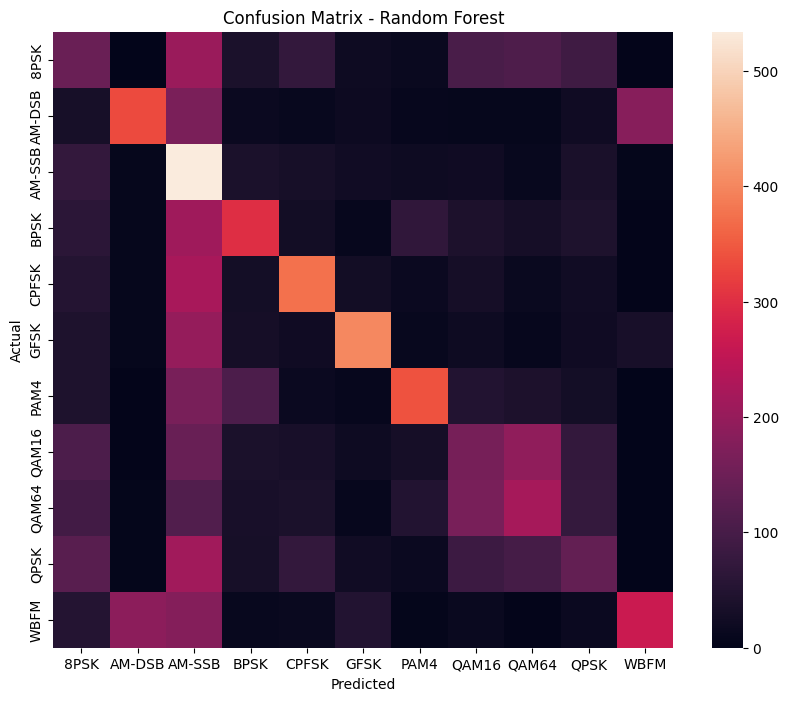

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.21227272727272728


### Model Comparison

All models are compared based on accuracy to determine the best-performing algorithm for modulation classification.

In [18]:
# Recompute predictions cleanly for comparison

y_pred_knn = knn.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)

y_pred_svm = svm.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

y_pred_lr = model.predict(X_test)  # Logistic Regression was stored in 'model'
lr_acc = accuracy_score(y_test, y_pred_lr)

# Re-train RF with separate variable (important fix)
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

In [19]:
results = {
    "KNN": knn_acc,
    "Linear SVM": svm_acc,
    "Logistic Regression": lr_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc
}

print("Model Comparison:\n")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

Model Comparison:

KNN: 0.2772
Linear SVM: 0.1542
Logistic Regression: 0.3651
Decision Tree: 0.2123
Random Forest: 0.3607


## 6. Signal Visualization

Signal visualization helps in understanding the structure of modulation schemes.

Two types of plots are used:
- Time-domain plots of I and Q components
- Constellation diagrams (I vs Q)

These visualizations highlight differences between modulation techniques.

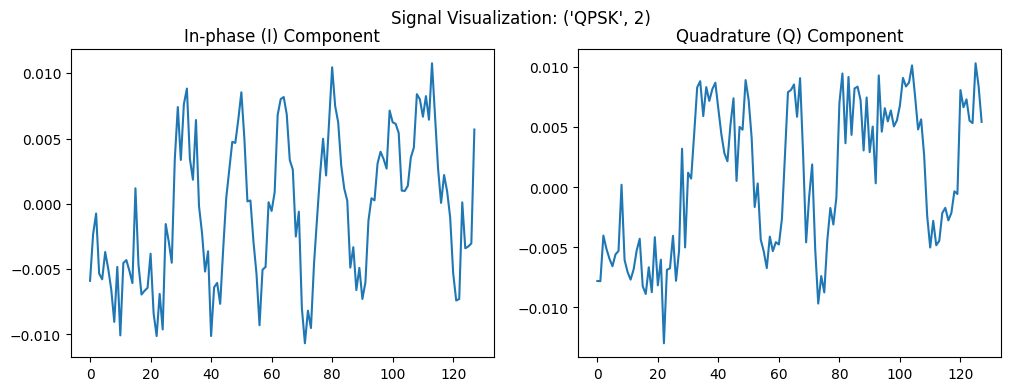

In [20]:
# Pick a sample signal
sample_key = list(data.keys())[0]
sample_signal = data[sample_key][0]

I = sample_signal[0]
Q = sample_signal[1]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(I)
plt.title("In-phase (I) Component")

plt.subplot(1, 2, 2)
plt.plot(Q)
plt.title("Quadrature (Q) Component")

plt.suptitle(f"Signal Visualization: {sample_key}")
plt.show()

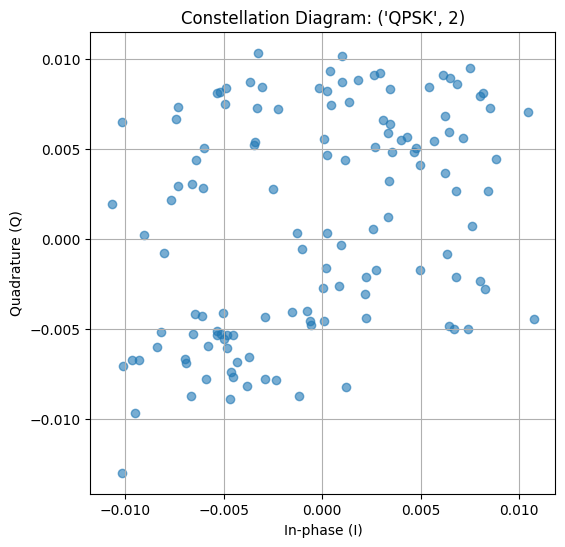

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(I, Q, alpha=0.6)

plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title(f"Constellation Diagram: {sample_key}")

plt.grid()
plt.show()

## 7. Principal Component Analysis (PCA)

PCA is used for dimensionality reduction:
- Reduces feature size from 256 to 50
- Retains most of the important variance
- Improves computational efficiency

The impact of PCA on model performance is also evaluated.

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)  # reduce from 256 → 50

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_pca.shape)

Original shape: (35200, 256)
Reduced shape: (35200, 50)


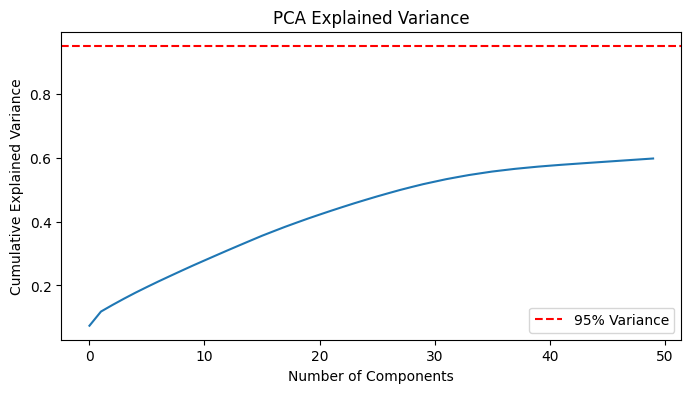

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.legend()
plt.show()

In [24]:
rf_pca = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

rf_pca.fit(X_train_pca, y_train)

y_pred_pca = rf_pca.predict(X_test_pca)

pca_acc = accuracy_score(y_test, y_pred_pca)

print("Random Forest Accuracy after PCA:", pca_acc)

Random Forest Accuracy after PCA: 0.3352272727272727


In [25]:
print("Without PCA:", rf_acc)
print("With PCA:", pca_acc)

Without PCA: 0.36068181818181816
With PCA: 0.3352272727272727


## 8. Feature Importance

Random Forest provides feature importance scores, which indicate how much each feature contributes to the model's decision.

This helps in understanding which parts of the signal are most relevant for classification.

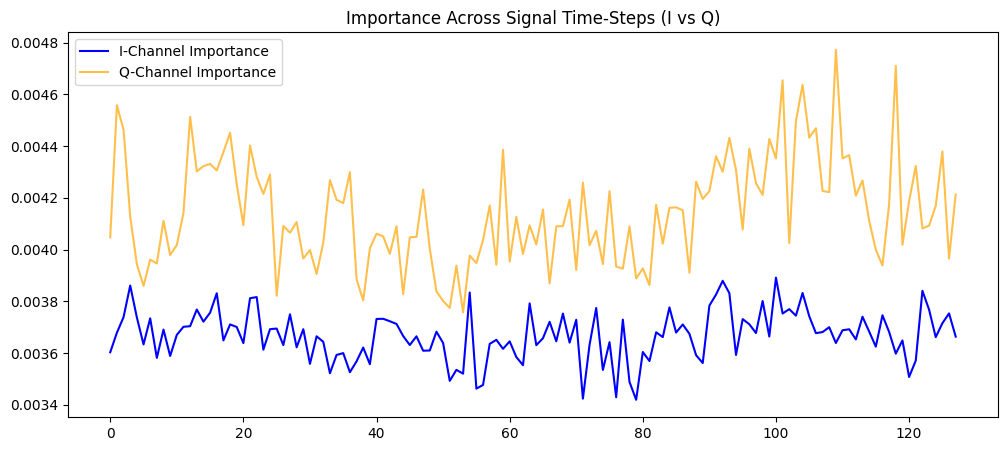

In [26]:
importances = rf.feature_importances_
imp_i = importances[:128]
imp_q = importances[128:256]

plt.figure(figsize=(12, 5))
plt.plot(imp_i, label='I-Channel Importance', color='blue')
plt.plot(imp_q, label='Q-Channel Importance', color='orange', alpha=0.7)
plt.title("Importance Across Signal Time-Steps (I vs Q)")
plt.legend()
plt.show()

## 9. Conclusion and Key Findings

### Model Performance Summary

This project demonstrated the use of machine learning techniques for Automatic Modulation Classification (AMC) using the RadioML 2016.10a dataset, which consists of raw I/Q signal samples under varying Signal-to-Noise Ratio (SNR) conditions.

- **Top Performer:** The Random Forest classifier achieved the highest accuracy (approximately 36-37% across all SNR levels). Its ensemble nature allows it to handle noisy and non-linear data more effectively than other models.

- **Comparison with Other Models:** Logistic Regression also performed competitively, indicating that certain modulation patterns remain linearly separable even in noisy environments. In contrast, Linear SVM showed comparatively lower performance, suggesting that margin-based separation struggles under high noise conditions.

- **Dimensionality Reduction (PCA):** Reducing feature dimensions from 256 to 50 using PCA resulted in only a marginal drop in accuracy (\~36% to \~33.5%). This indicates that a reduced set of principal components captures a significant portion of the signal variance (\~60%), improving computational efficiency with minimal loss in performance.

---

### Signal-Level Insights (EEE Perspective)

- **Effect of Noise (SNR):** The relatively low overall accuracy is primarily due to the inclusion of very low SNR signals (down to -20 dB), where noise heavily distorts the signal, making classification inherently difficult.

- **Constellation Overlap:** The confusion matrix shows that higher-order modulation schemes (e.g., QAM16 vs. QAM64, and 8PSK) are frequently misclassified. This is consistent with communication theory, as these schemes have closely spaced constellation points, which overlap significantly under noisy conditions.

- **I/Q Component Analysis:** Feature importance analysis suggests that the Quadrature (Q) component contributes slightly more discriminative information at certain time steps compared to the In-phase (I) component for this dataset subset.

---

### Final Remarks

This project establishes that traditional machine learning models can serve as a strong baseline for modulation classification. However, their performance is limited when dealing with raw, noisy signal data, especially when temporal relationships are not explicitly modeled.

---

### Future Work

- Implement deep learning models such as Convolutional Neural Networks (CNNs) or LSTMs to capture temporal and spatial dependencies in I/Q signals  
- Analyze model performance across different SNR levels for more detailed insights  
- Explore real-world RF datasets for practical deployment scenarios  

---

### AI Usage Disclosure

AI tools were used during this project for:
- Generating initial code structure  
- Debugging implementation issues  
- Suggesting improvements to the machine learning pipeline  

All outputs were carefully reviewed, tested, and understood before inclusion.